In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from core.data import load_from_kaggle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
from collections import defaultdict

c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "saireddypothireddy/human-data-sequence-dataset" # replace with your dataset link from Kaggle 
destination = "../../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../../data/raw\human-data-sequence-dataset' already exists with files. Skipping download (replace=False).


In [3]:
files

['Human Data Sequnence.txt']

In [4]:
my_path = "../../data/raw/human-data-sequence-dataset/Human Data Sequnence.txt"
with open(my_path, "r") as f:
    file = f.read()
file[:500]

'sequence\tclass\nATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCATACTCCTTACACTATTCCTCATCACCCAACTAAAAATATTAAACACAAACTACCACCTACCTCCCTCACCAAAGCCCATAAAAATAAAAAATTATAACAAACCCTGAGAACCAAAATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG\t4\nATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAGGCCTACCCGCCGCAGTACTGATCATTCTATTTCCCCCTCTATTGATCCCCACCTCCAAATATCTCATCAACAACCGACTAATCACCACCCAACAATGACTAATCAAACTAACCTCAAAACAAATGATAACCATACACAACACTAAAGGACGAACCTGATCTCTTATACTAGTATCCTTAATCATTTTTATTGCCACAACTAACCTCCTCGGACTCCTGCCTCACTCATT'

In [5]:
df = pd.read_csv(my_path, sep='\t')
sequences = df["sequence"].values
df.head()

,sequence,class
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3


In [6]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(4380, 2)

'Description'

,count,mean,std,min,25%,50%,75%,max
class,4380.0,3.5,2.13,0.0,2.0,4.0,6.0,6.0


'Duplicates'

np.int64(751)

,Data Types,Missing Values,Unique Values,Sample Values
sequence,object,0,3629,[ATGGGGTCTGCTGGCTTGTCGCGGCTGCATGGGCTTTTCGCGGTC...
class,int64,0,7,"[5, 0, 6]"


In [7]:
#Number of exact duplicates
sequences = df['sequence'].values
seq_to_indices = defaultdict(list)

for i, seq in enumerate(sequences):
    seq_to_indices[seq].append(i)

duplicates = {seq: idxs for seq, idxs in seq_to_indices.items() if len(idxs) > 1}

print(f"Anzahl exakter Duplikate: {len(duplicates)}")

Anzahl exakter Duplikate: 489


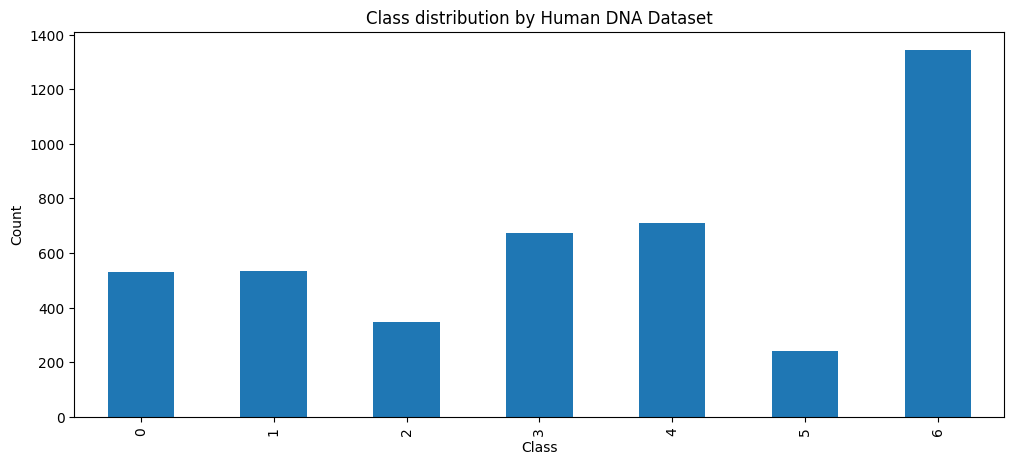

In [8]:
#Class distribution of Human DNA
fig, ax = plt.subplots(figsize=(12, 5))

df['class'].value_counts().sort_index().plot.bar(ax=ax)

ax.set_title("Class distribution by Human DNA Dataset")
ax.set_ylabel("Count")
ax.set_xlabel("Class")

plt.show()

In [9]:
#search the best k-mer value for clustering
for k in [3, 4, 5]:
    vectorizer = CountVectorizer(analyzer="char", ngram_range=(k, k))
    X = vectorizer.fit_transform(sequences)
    X_scaled = StandardScaler(with_mean=False).fit_transform(X)
    clusters = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters)
    print(f"k-mer={k}, silhouette={score:.3f}")

k-mer=3, silhouette=0.373
k-mer=4, silhouette=0.315
k-mer=5, silhouette=0.267


In [10]:
#K-mer Feature Extraction
k = 3 
vectorizer = CountVectorizer(analyzer="char", ngram_range=(k, k))
X = vectorizer.fit_transform(sequences)

scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

n_clusters = 3
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)
df["cluster"] = clusters
display(df)

,sequence,class,cluster
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,0
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,0
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,0
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,1
...,...,...,...
4375,ATGGAAGATTTGGAGGAAACATTATTTGAAGAATTTGAAAACTATT...,0,0
4376,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2
4377,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2
4378,ATGGGGCACCTGGTTTGCTGTCTGTGTGGCAAGTGGGCCAGTTACC...,6,0


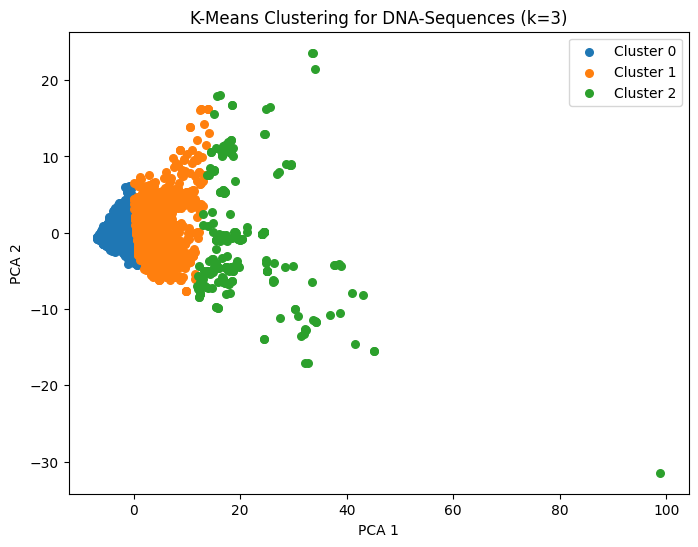

In [11]:
#PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled.toarray())
unique_clusters = np.unique(clusters)
plt.figure(figsize=(8, 6))

for cluster_id in unique_clusters:
    idx=clusters==cluster_id
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=30,
        label=f"Cluster {cluster_id}"
    )
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering for DNA-Sequences (k=3)")
plt.legend()
plt.show()

In [12]:
#Top features for PCA1 and PCA2
feature_names = vectorizer.get_feature_names_out()
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"])

pc1_top_pos = loadings["PC1"].sort_values(ascending=False).head(10)
pc1_top_neg = loadings["PC1"].sort_values().head(10)

pc2_top_pos = loadings["PC2"].sort_values(ascending=False).head(10)
pc2_top_neg = loadings["PC2"].sort_values().head(10)

ca=ca = pd.DataFrame({
    "PCA1_pos_kmer": pc1_top_pos.index,
    "PCA1_pos_loading": pc1_top_pos.values,
    "PCA1_neg_kmer": pc1_top_neg.index,
    "PCA1_neg_loading": pc1_top_neg.values,
    "PCA2_pos_kmer": pc2_top_pos.index,
    "PCA2_pos_loading": pc2_top_pos.values,
    "PCA2_neg_kmer": pc2_top_neg.index,
    "PCA2_neg_loading": pc2_top_neg.values,
})
print('Top features for PCA1 and PCA2')
ca.head(10)

Top features for PCA1 and PCA2


,PCA1_pos_kmer,PCA1_pos_loading,PCA1_neg_kmer,PCA1_neg_loading,PCA2_pos_kmer,PCA2_pos_loading,PCA2_neg_kmer,PCA2_neg_loading
0,tca,0.136402,nag,-0.009849,cgc,0.242290,taa,-0.194211
1,gga,0.136206,nng,-0.009385,ccg,0.237585,tta,-0.190739
2,cat,0.135930,ntg,-0.007721,cgg,0.236157,ata,-0.190125
3,atc,0.135574,nnc,-0.007550,gcg,0.236032,att,-0.181355
4,tga,0.135415,ngg,-0.007430,gcc,0.195143,aat,-0.177705
5,atg,0.135307,nna,-0.006808,ccc,0.194590,aaa,-0.175141
6,gtc,0.135210,nga,-0.006724,ggc,0.193493,tat,-0.167967
7,gac,0.135128,ngc,-0.006584,ggg,0.164733,ttt,-0.166446
8,tgg,0.134979,nnt,-0.005979,acg,0.163878,tag,-0.155458
9,aca,0.134947,nac,-0.005463,cgt,0.151267,ttg,-0.133232


In [13]:
#DNA classification
#calculation of Sequence_Length, A_freq, C_freq, G_freq, T_freq, GC_Content
def global_features(seq):
    length = len(seq)
    counts = Counter(seq)

    a = counts.get("A", 0) / length
    c = counts.get("C", 0) / length
    g = counts.get("G", 0) / length
    t = counts.get("T", 0) / length
    gc = g + c

    return [length, a, c, g, t, gc]

X_global = np.array([global_features(seq) for seq in sequences])

In [14]:
#create of new columns in dataphram
df['seq_length'] = X_global[:, 0]
df['A_freq'] = X_global[:, 1]
df['C_freq'] = X_global[:, 2]
df['G_freq'] = X_global[:, 3]
df['T_freq'] = X_global[:, 4]
df['GC_content'] = X_global[:, 5]
display(df)

,sequence,class,cluster,seq_length,A_freq,C_freq,G_freq,T_freq,GC_content
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,0,207.0,0.386473,0.333333,0.062802,0.217391,0.396135
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,0,681.0,0.302496,0.337739,0.104258,0.255507,0.441997
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1,1686.0,0.282325,0.198102,0.233096,0.286477,0.431198
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,0,1206.0,0.281095,0.174129,0.243781,0.300995,0.417910
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,1,1437.0,0.290188,0.200418,0.226862,0.282533,0.427279
...,...,...,...,...,...,...,...,...,...
4375,ATGGAAGATTTGGAGGAAACATTATTTGAAGAATTTGAAAACTATT...,0,0,57.0,0.385965,0.105263,0.192982,0.315789,0.298246
4376,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2,5883.0,0.278259,0.262111,0.258882,0.200748,0.520993
4377,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2,5817.0,0.279354,0.259584,0.259240,0.201822,0.518824
4378,ATGGGGCACCTGGTTTGCTGTCTGTGTGGCAAGTGGGCCAGTTACC...,6,0,753.0,0.252324,0.258964,0.292165,0.196547,0.551129


In [15]:
#calculation of kmer3_freq
k = 3
vectorizer = CountVectorizer(
    analyzer="char",
    ngram_range=(k, k)
)

X_kmer = vectorizer.fit_transform(sequences).toarray()

# Normierung auf Sequenzlänge
X_kmer_freq = X_kmer / X_kmer.sum(axis=1, keepdims=True)
feature_names = vectorizer.get_feature_names_out()
kmer_freq_df = pd.DataFrame(X_kmer_freq, columns=feature_names)
kmer_freq_df["sequence"] = sequences
cols = ["sequence"] + [col for col in kmer_freq_df.columns if col != "sequence"]
kmer_freq_df = kmer_freq_df[cols]
kmer_freq_df

,sequence,aaa,aac,aag,aat,aca,acc,acg,act,aga,...,tcg,tct,tga,tgc,tgg,tgt,tta,ttc,ttg,ttt
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,0.092683,0.039024,0.004878,0.039024,0.024390,0.048780,0.004878,0.029268,0.004878,...,0.004878,0.004878,0.009756,0.009756,0.004878,0.004878,0.019512,0.019512,0.004878,0.000000
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,0.020619,0.032401,0.008837,0.023564,0.029455,0.036819,0.007364,0.027982,0.002946,...,0.008837,0.022091,0.013255,0.010309,0.004418,0.002946,0.022091,0.020619,0.005891,0.011782
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,0.023159,0.013658,0.027910,0.020190,0.018409,0.010095,0.004157,0.016033,0.030285,...,0.003563,0.018409,0.029691,0.016033,0.027316,0.017815,0.015439,0.020190,0.024941,0.036817
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,0.024917,0.014120,0.029900,0.018272,0.022425,0.007475,0.002492,0.014120,0.029070,...,0.003322,0.014120,0.025748,0.017442,0.032392,0.025748,0.014950,0.015781,0.032392,0.046512
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,0.025784,0.014634,0.029965,0.018815,0.018118,0.009059,0.004878,0.018118,0.030662,...,0.003484,0.018815,0.029268,0.013937,0.025784,0.014634,0.017422,0.020209,0.022300,0.036934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4375,ATGGAAGATTTGGAGGAAACATTATTTGAAGAATTTGAAAACTATT...,0.054545,0.036364,0.036364,0.018182,0.018182,0.018182,0.000000,0.018182,0.036364,...,0.000000,0.000000,0.054545,0.000000,0.036364,0.000000,0.018182,0.018182,0.054545,0.054545
4376,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,0.022785,0.014113,0.028226,0.013773,0.020575,0.017514,0.003741,0.011903,0.029247,...,0.003401,0.015474,0.017514,0.015304,0.022615,0.009522,0.009012,0.014963,0.008842,0.012073
4377,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,0.022872,0.014101,0.028203,0.013929,0.020464,0.017541,0.003783,0.012210,0.029407,...,0.003267,0.015477,0.017885,0.015133,0.023044,0.009802,0.009114,0.014961,0.008770,0.012210
4378,ATGGGGCACCTGGTTTGCTGTCTGTGTGGCAAGTGGGCCAGTTACC...,0.019973,0.006658,0.030626,0.013316,0.017310,0.018642,0.002663,0.013316,0.027963,...,0.006658,0.013316,0.018642,0.017310,0.027963,0.015979,0.009321,0.007989,0.015979,0.015979


C:\Users\yamen\AppData\Local\Temp\ipykernel_9532\1675705085.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_kmers["kmer"], rotation=45)  # rotate x-axis labels


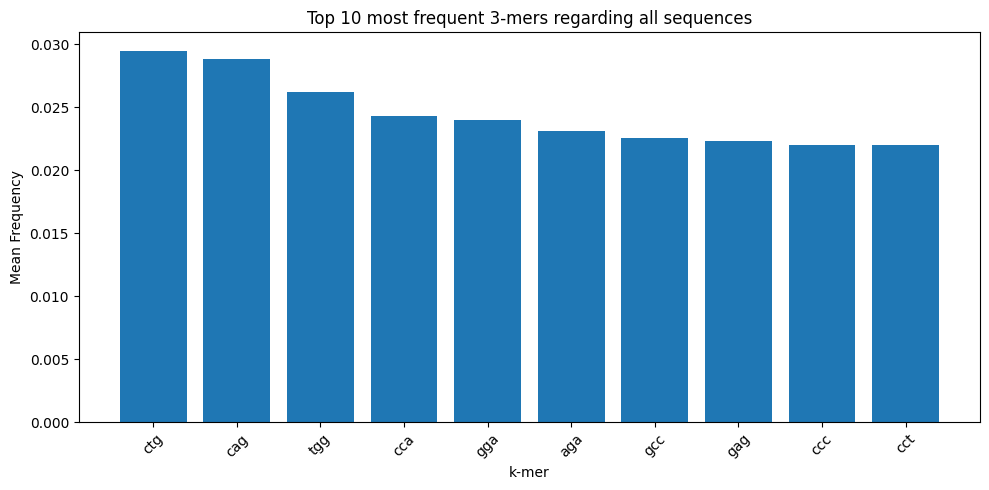

In [16]:
#calculation and visualization of mean value for each kmer regarding all sequences
kmer_means = kmer_freq_df.drop(columns=["sequence"]).mean()
kmer_means_df = kmer_means.reset_index()
kmer_means_df.columns = ["kmer", "mean_frequency"]
kmer_means_df = kmer_means_df.sort_values(by='mean_frequency', ascending=False)
# visualization of top ten mean 
top_kmers = kmer_means_df.head(10)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(top_kmers["kmer"], top_kmers["mean_frequency"])
ax.set_xlabel("k-mer")
ax.set_ylabel("Mean Frequency")
ax.set_title("Top 10 most frequent 3-mers regarding all sequences")
ax.set_xticklabels(top_kmers["kmer"], rotation=45)  # rotate x-axis labels

fig.tight_layout()
plt.show()


In [17]:
#kmer frequency mean for each sequence
kmer3_freq_mean = X_kmer_freq.mean(axis=1).round(5)
df['kmer_frequeny_mean'] = kmer3_freq_mean
df

,sequence,class,cluster,seq_length,A_freq,C_freq,G_freq,T_freq,GC_content,kmer_frequeny_mean
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,0,207.0,0.386473,0.333333,0.062802,0.217391,0.396135,0.0119
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,0,681.0,0.302496,0.337739,0.104258,0.255507,0.441997,0.0119
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1,1686.0,0.282325,0.198102,0.233096,0.286477,0.431198,0.0119
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,0,1206.0,0.281095,0.174129,0.243781,0.300995,0.417910,0.0119
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,1,1437.0,0.290188,0.200418,0.226862,0.282533,0.427279,0.0119
...,...,...,...,...,...,...,...,...,...,...
4375,ATGGAAGATTTGGAGGAAACATTATTTGAAGAATTTGAAAACTATT...,0,0,57.0,0.385965,0.105263,0.192982,0.315789,0.298246,0.0119
4376,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2,5883.0,0.278259,0.262111,0.258882,0.200748,0.520993,0.0119
4377,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2,5817.0,0.279354,0.259584,0.259240,0.201822,0.518824,0.0119
4378,ATGGGGCACCTGGTTTGCTGTCTGTGTGGCAAGTGGGCCAGTTACC...,6,0,753.0,0.252324,0.258964,0.292165,0.196547,0.551129,0.0119


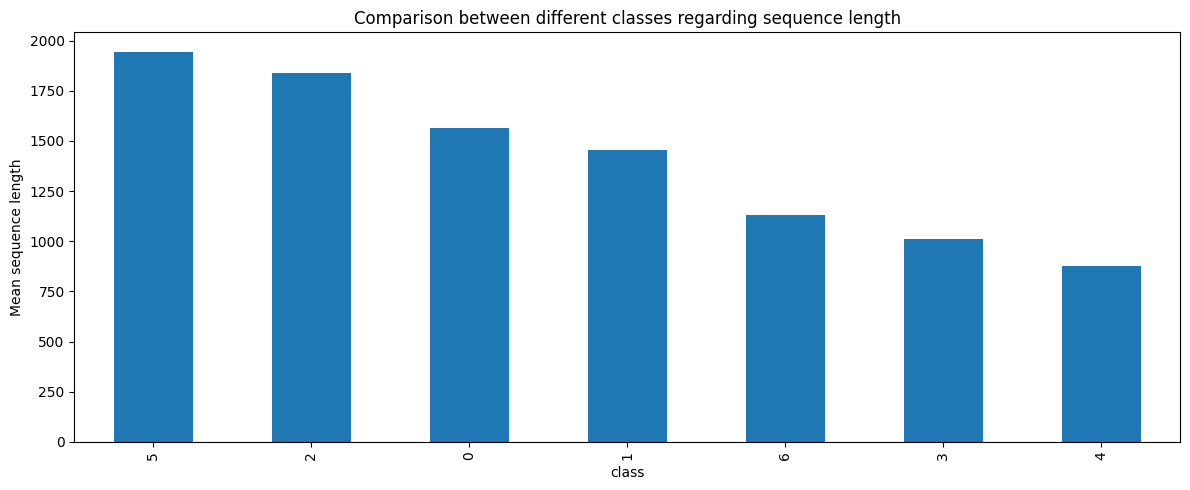

In [18]:
#comparison between different classes regarding sequence length
mean_length = df.groupby("class")["seq_length"].mean()

fig, ax = plt.subplots(figsize=(12, 5))

mean_length.sort_values(ascending=False).plot.bar(ax=ax)

ax.set_title('Comparison between different classes regarding sequence length')
ax.set_ylabel('Mean sequence length')

plt.tight_layout()
plt.show()

In [19]:
#generation of class list
labels = []
with open(my_path, "r") as f:
    f.readline()  # Header
    for line in f:
        seq, cls = line.strip().split("\t")
        labels.append(int(cls))

In [20]:
#generation of unique lists for training
seq_label_pairs = list(zip(sequences, labels))
counts = Counter(seq_label_pairs)

unique_seq = []
unique_labels = []
weights = []

for (seq, label), count in counts.items():
    unique_seq.append(seq)
    unique_labels.append(label)
    weights.append(count)

In [21]:
#training and generation of classification report
X_global = np.array([global_features(seq) for seq in unique_seq])
X_kmer = vectorizer.fit_transform(unique_seq).toarray()
X = np.hstack([X_global, X_kmer])
y = np.array(unique_labels)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_scaled,
    y,
    weights,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train, y_train, sample_weight=w_train)
y_pred = clf.predict(X_test)
print('classification_report')
print('\n')
print(classification_report(y_test, y_pred))

classification_report


              precision    recall  f1-score   support

           0       0.86      0.72      0.79        89
           1       0.84      0.50      0.63        82
           2       0.83      0.59      0.69        58
           3       0.69      0.61      0.65       114
           4       0.58      0.68      0.62       118
           5       1.00      0.58      0.74        43
           6       0.69      0.93      0.79       222

    accuracy                           0.72       726
   macro avg       0.78      0.66      0.70       726
weighted avg       0.74      0.72      0.71       726



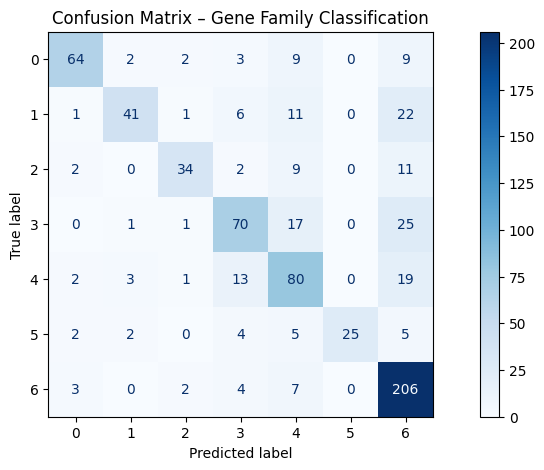

In [22]:
#generation of confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(12, 5))

disp.plot(ax=ax, cmap="Blues", values_format="d")

ax.set_title("Confusion Matrix – Gene Family Classification")

plt.show()

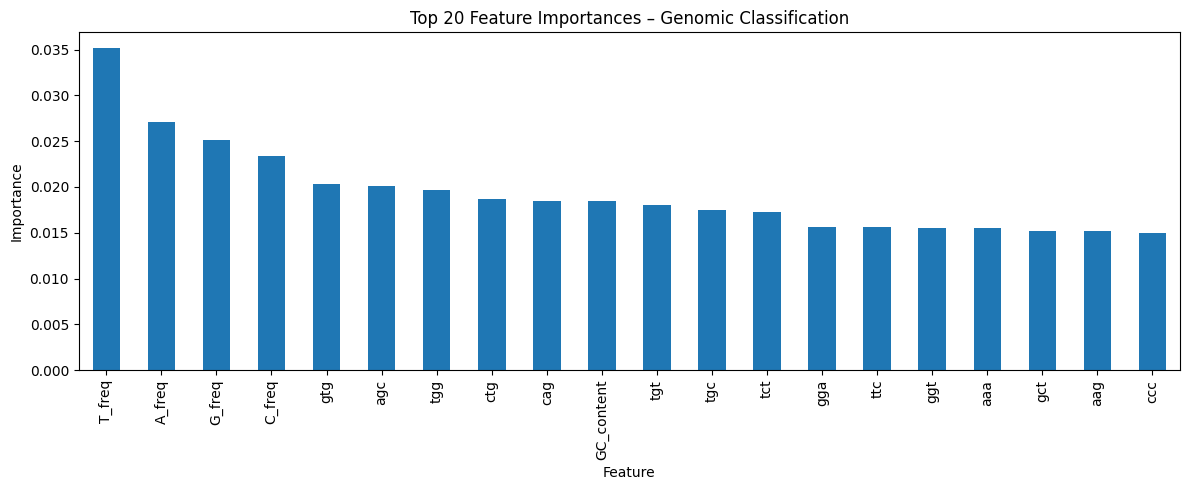

In [23]:
#visualization of feature importances
global_feature_names = [
    "seq_length",
    "A_freq",
    "C_freq",
    "G_freq",
    "T_freq",
    "GC_content"
]
kmer_feature_names = vectorizer.get_feature_names_out()
feature_names = np.concatenate([global_feature_names, kmer_feature_names])

importances = clf.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))

fi.iloc[:20].plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False,
    ax=ax
)

ax.set_ylabel("Importance")
ax.set_xlabel("Feature")
ax.set_title("Top 20 Feature Importances – Genomic Classification")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [24]:
X_df = pd.DataFrame(X, columns=feature_names)
X_df["label"] = y

mean_features = X_df.groupby("label").mean()

mean_features_20 = mean_features.loc[6].sort_values(ascending=False).iloc[:20]
mean_features_20

seq_length    1037.057710
cag             34.279531
cca             27.886384
aga             27.169522
ccc             25.393147
agc             25.353472
ctg             25.311091
gaa             25.267809
aag             24.980162
aaa             23.496844
gga             23.343553
gcc             23.241659
gag             22.926961
gca             22.059513
cct             22.024346
tgg             21.365194
caa             21.235347
agg             20.676285
ggc             20.294860
tcc             20.149684
Name: 6, dtype: float64

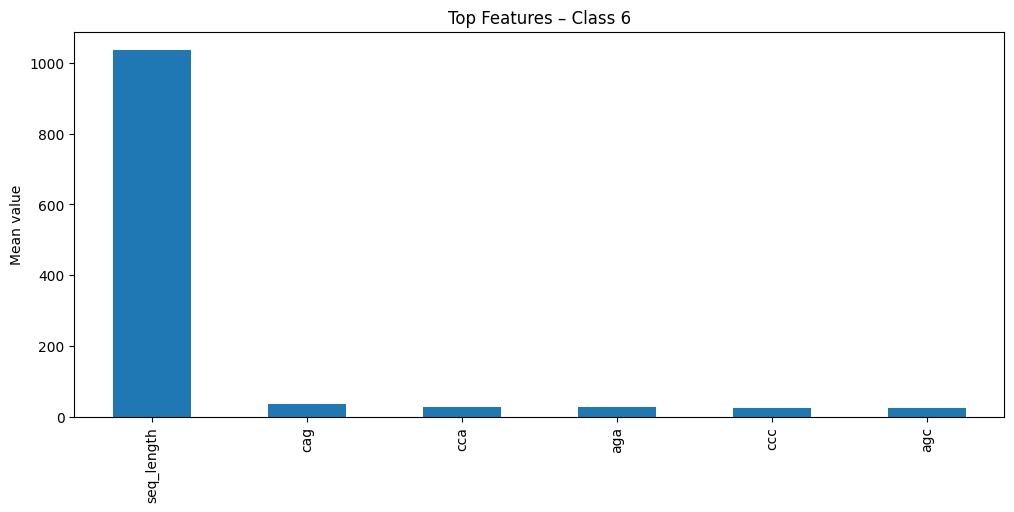

In [25]:
global_feats = [
    "seq_length", "A_freq", "C_freq", "G_freq", "T_freq", "GC_content"
]
#top characterestic features for class 6
mean_features_6 = mean_features.loc[6].sort_values(ascending=False).iloc[:6]

mean_features_6.plot(kind="bar", figsize=(12,5))
plt.title("Top Features – Class 6")
plt.ylabel("Mean value")
plt.show()

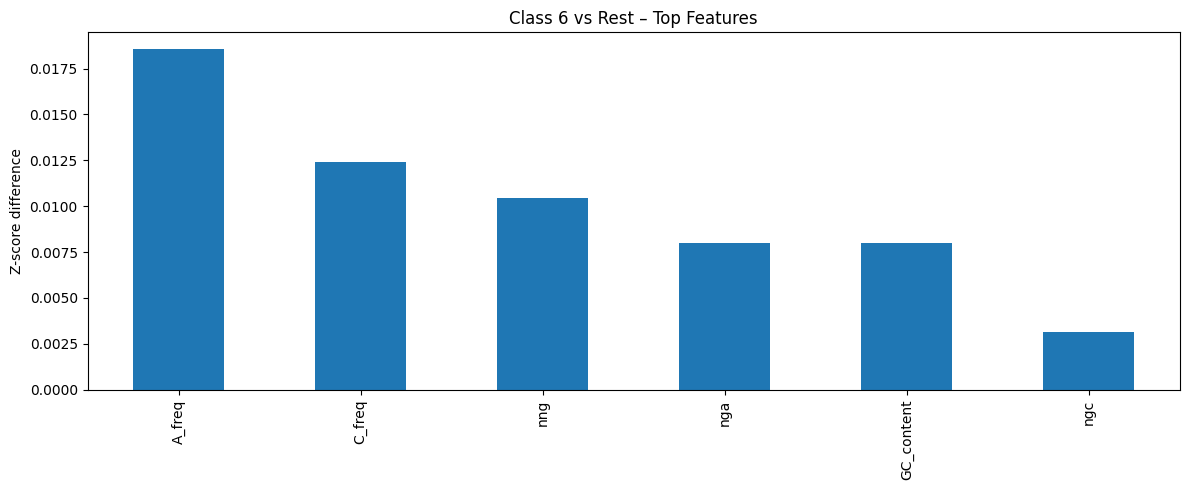

In [29]:
mean_6 = mean_features.loc[6]
mean_rest = mean_features.drop(6).mean()

diff = (mean_6 - mean_rest).sort_values(ascending=False).iloc[:6]
plt.figure(figsize=(12,5))
diff.plot(kind="bar")
plt.ylabel("Z-score difference")
plt.title("Class 6 vs Rest – Top Features")
plt.tight_layout()

C:\Users\yamen\AppData\Local\Temp\ipykernel_9532\2598193007.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(global_feats_6.index, rotation=90)


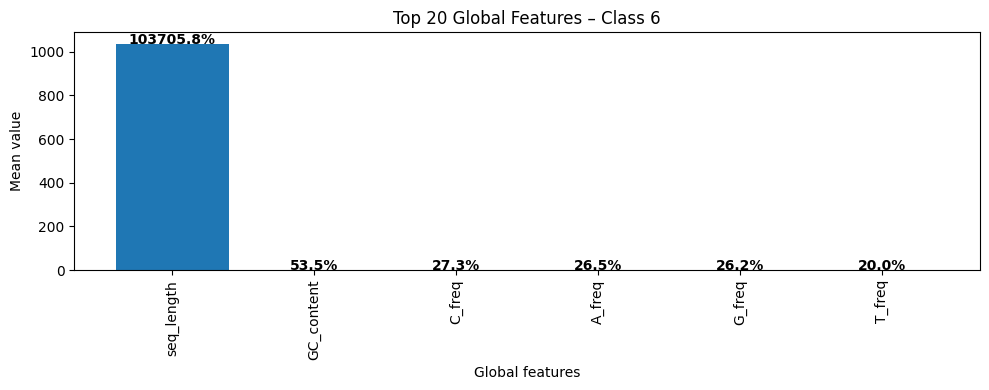

In [27]:
global_feats = [f for f in mean_features.columns if f in global_feature_names]
global_feats_6 =  mean_features.loc[6, global_feats].sort_values(ascending=False).iloc[:20]
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(global_feats_6.index, global_feats_6.values)
ax.set_title("Top 20 Global Features – Class 6")
ax.set_ylabel("Mean value")
ax.set_xlabel("Global features")
ax.set_xticklabels(global_feats_6.index, rotation=90)
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha='center',
        fontweight='bold',
        fontsize=10
    );

plt.tight_layout()
plt.show()


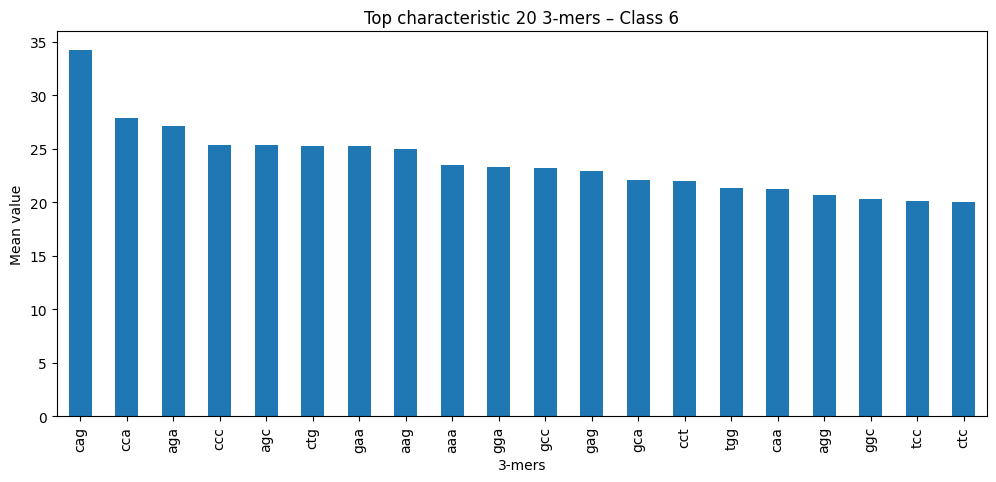

In [30]:
kmer_feats = [f for f in mean_features.columns if len(f) == 3]

mean_kmer_6 = mean_features.loc[6, kmer_feats].sort_values(ascending=False).iloc[:20]

mean_kmer_6.plot(kind="bar", figsize=(12,5))
plt.title("Top characteristic 20 3-mers – Class 6")
plt.ylabel("Mean value")
plt.xticks(rotation=90)
plt.xlabel('3-mers')
plt.show()

**Discussion**:


This dataset contains human DNA sequences grouped according to their gene families. Each entry includes:

-**DNA Sequence** – A string of nucleotides (A, T, G, C).

-**Class / Gene Family** – The functional or structural group the sequence belongs to.

-**Sequence Length** – Automatically computable and useful for downstream QC.

This dataphram contains 4380 raws and 2 columns inclusiv DNA sequences with their classes. 

The number of duplicates in this dataset is 751. The number of exact duplicates is 489. 

**Clustering**:

For clustering here we applied KMeans and PCA for visualization. I set kmers of 3 because in biology each three nucleotides encode one amino acid. We can see at the end three clusters. Each point represents three nucleotides sequence. I reduced dimensions using PCA (2 components) and plotted the sequences in 2D(PCA1, PCA2).
These clusters were formed based on distance in 64-dimensional k-mer space, not in PCA space. We can notice the largest variance in codon patterns by PCA1 by clustering. Custer 0 is Very compact and located on the left in the negative range of PCA1. It has small spread. In other words cluster 0 has highly similar sequences. Cluster 1 overlaps partially with cluster 0 and has slightly more spread compared to cluster 0. It is positioned further to the right in PCA1 range. Cluster 1 has high diversity of sequences compared to cluster 0. Cluster 2 has large variance and shows some extreme outliers. It has heterogeneous sequences compared to other clusters. We can see an outlier at PCA1 100. We can interpretate that by abnormal codon composition or by data artifact. Cluster 2 looks like the most biologically diverse group.

**Classification**:

I calculated sequence length, frequency of nucleotides (a, c, g, t) and contet(gc) for each sequence( global features). I calculated also kmer3_freq_mean for each sequnce. We use here unique sequences for training to exclude the influence of duplicates of our results. Here I used  random forest model for classification. I got at the end the classification report. The model favors Class 6 due to relative highest recall and F1 score as well as largest support (222). By class 5 for example we have relative the highest precision but low recall values. That means this model misses many real class 5 sequences. Class 6 likely represents more heterogeneous genes or background genomic pattern. By confusion matrix rows represent true gene family and columns represent predicted gene family. I can merk that class 6 has a very strong and distinct feature profile due to very few misclassifications compared to other classes(True 6 → Predicted 6 = 206). There is relatively good similarity between class 3 and class 6(True 3 → Predicted 6 = 25). 